In [34]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Dagshub/Mlflow initialization

In [35]:
pip install dagshub mlflow scikit-learn pandas matplotlib seaborn skops --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
import dagshub
import mlflow
import mlflow.sklearn

dagshub.init(repo_owner='myvari', repo_name='House-Prices', mlflow=True)

Initialized MLflow to track repo "myvari/House-Prices"

Repository myvari/House-Prices initialized!

# Exploratory Data Analysis

In [37]:
df = pd.read_csv('data/raw/train.csv')

In [38]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

#y_bins = pd.qcut(y, q=10, labels=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (1168, 80)
Test size:  (292, 80)


In [39]:
X_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1066,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal
638,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal
799,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal
380,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal


In [40]:
X_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1168.000000,1168.000000,951.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1162.000000,1168.000000,...,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000
mean,730.904966,56.849315,70.343849,10689.642123,6.121575,5.584760,1970.965753,1984.897260,103.771945,446.023973,...,476.273973,95.946918,49.578767,21.839041,3.812500,15.407534,2.955479,51.267123,6.356164,2007.818493
std,425.369088,42.531862,24.897021,10759.366198,1.367619,1.116062,30.675495,20.733955,173.032238,459.070977,...,211.095373,129.685939,69.433580,62.083227,31.519664,55.881148,41.648504,553.039684,2.670707,1.322639
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,360.750000,20.000000,59.000000,7587.250000,5.000000,5.000000,1953.000000,1966.000000,0.000000,0.000000,...,341.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000
50%,732.500000,50.000000,70.000000,9600.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,384.500000,...,482.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,1101.750000,70.000000,80.000000,11700.000000,7.000000,6.000000,2001.000000,2004.000000,166.000000,721.000000,...,576.000000,168.000000,74.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1378.000000,5644.000000,...,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000


In [41]:
X_train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      217
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
Length: 80, dtype: int64

In [42]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 254 to 1126
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    951 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          74 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallCond

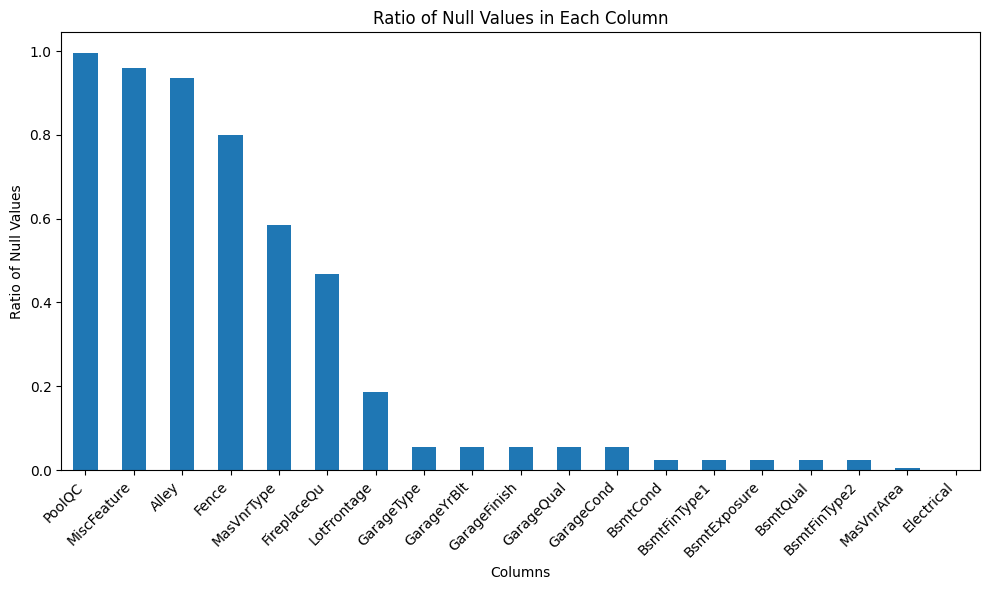

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

nulls_ratio = X_train.isnull().sum() / X_train.shape[0]
nulls_ratio = nulls_ratio[nulls_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
nulls_ratio.plot(kind='bar')
plt.title('Ratio of Null Values in Each Column')
plt.xlabel('Columns')
plt.ylabel('Ratio of Null Values')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Many of those Null heavy columns carry information about that feature, careful analysis needed.

In [44]:
# Count numerical and categorical columns in X_train
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object']).columns

print(f"Numerical columns ({len(numerical_cols)}): {list(numerical_cols)}")
print(f"Categorical columns ({len(categorical_cols)}): {list(categorical_cols)}")

Numerical columns (37): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu'

Check out missing numeric entries

In [45]:
numeric_nulls = X_train[numerical_cols].isnull().sum()[X_train[numerical_cols].isnull().sum() > 0] 

In [46]:
numeric_null_cols = numeric_nulls.index.tolist()

lot_exists = X_train["LotArea"][X_train["LotArea"] > 0]
masvnr_exists = X_train["MasVnrType"].notna()
garage_exists = X_train["GarageType"].notna()

for col, indicator, label in [
    ("LotFrontage", lot_exists, "Lot exists (LotArea > 0)"),
    ("MasVnrArea", masvnr_exists, "MasVnr exists (MasVnrType notna)"),
    ("GarageYrBlt", garage_exists, "Garage exists (GarageType notna)"),
]:
    if col in numeric_null_cols:
        nulls = X_train[col].isna()
        print(f"=== {col} ===")
        print(f"Total nulls: {nulls.sum()}")
        print(f"Nulls when {label} is False: {(nulls & ~indicator).sum()}")
        print(f"Nulls when {label} is True: {(nulls & indicator).sum()}")
        print()

print(f"GarageYrBlt == 0: {X_train['GarageYrBlt'][X_train['GarageYrBlt'] == 0].count()}")
print(f"MasVnrArea == 0: {X_train['MasVnrArea'][X_train['MasVnrArea'] == 0].count()}")
print(f"LotFrontage == 0: {X_train['LotFrontage'][X_train['LotFrontage'] == 0].count()}")

=== LotFrontage ===
Total nulls: 217
Nulls when Lot exists (LotArea > 0) is False: 134
Nulls when Lot exists (LotArea > 0) is True: 83

=== MasVnrArea ===
Total nulls: 6
Nulls when MasVnr exists (MasVnrType notna) is False: 6
Nulls when MasVnr exists (MasVnrType notna) is True: 0

=== GarageYrBlt ===
Total nulls: 64
Nulls when Garage exists (GarageType notna) is False: 64
Nulls when Garage exists (GarageType notna) is True: 0

GarageYrBlt == 0: 0
MasVnrArea == 0: 674
LotFrontage == 0: 0


## Numeric feature histograms

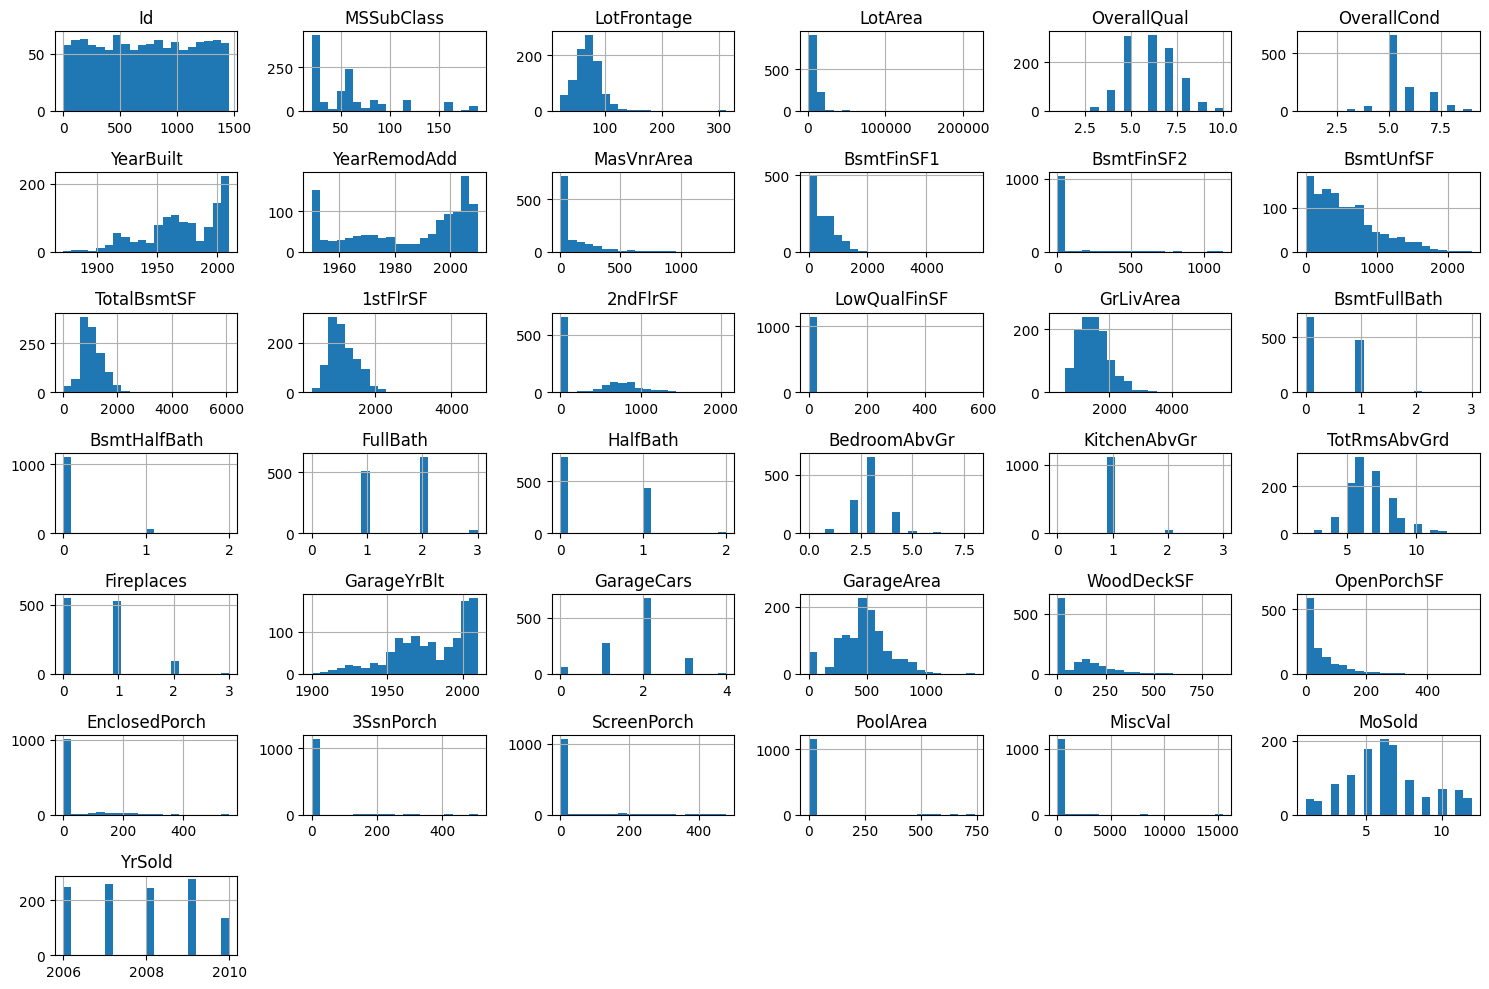

In [47]:
X_train[numerical_cols].hist(bins=20, figsize=(15, 10))
plt.tight_layout()
plt.show()

## Target Sale Histogram, skewness analysis

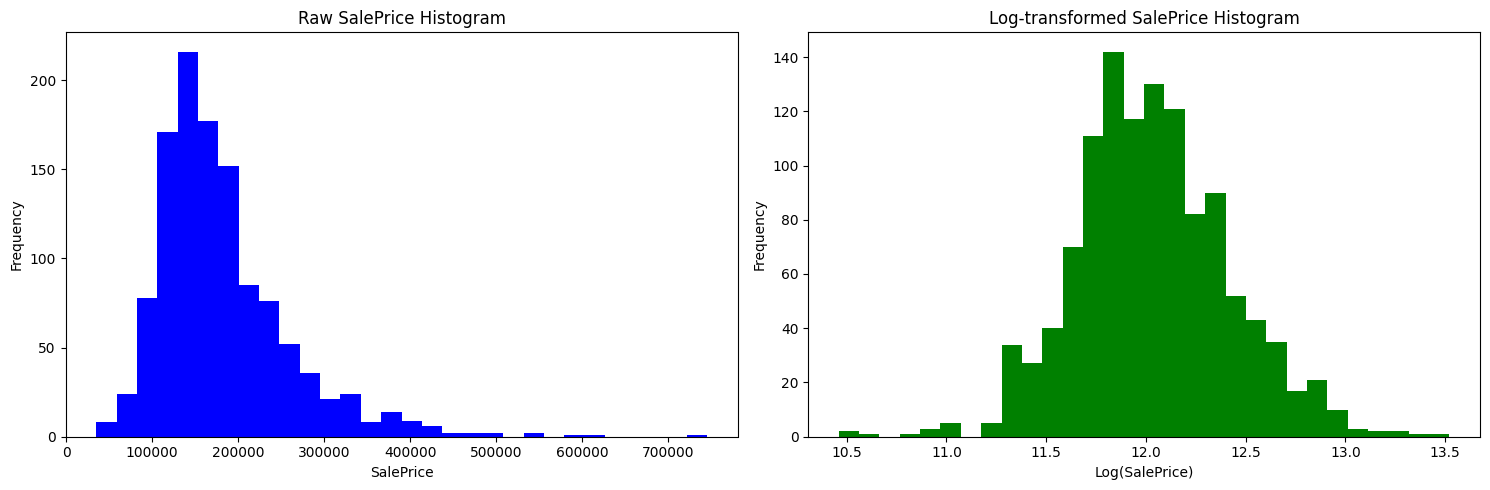

Raw SalePrice skewness: 1.743128561420854
Log-transformed SalePrice skewness: 0.12487950942382703


In [48]:
plt.figure(figsize=(15, 5))

# Raw SalePrice histogram
plt.subplot(1, 2, 1)
plt.hist(y_train, bins=30, color='blue')
plt.title('Raw SalePrice Histogram')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')

# Log-transformed SalePrice histogram
plt.subplot(1, 2, 2)
plt.hist(y_train_log, bins=30, color='green')
plt.title('Log-transformed SalePrice Histogram')
plt.xlabel('Log(SalePrice)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Raw SalePrice skewness: {y_train.skew()}")
print(f"Log-transformed SalePrice skewness: {y_train_log.skew()}")

## Numeric feature importance and correlation

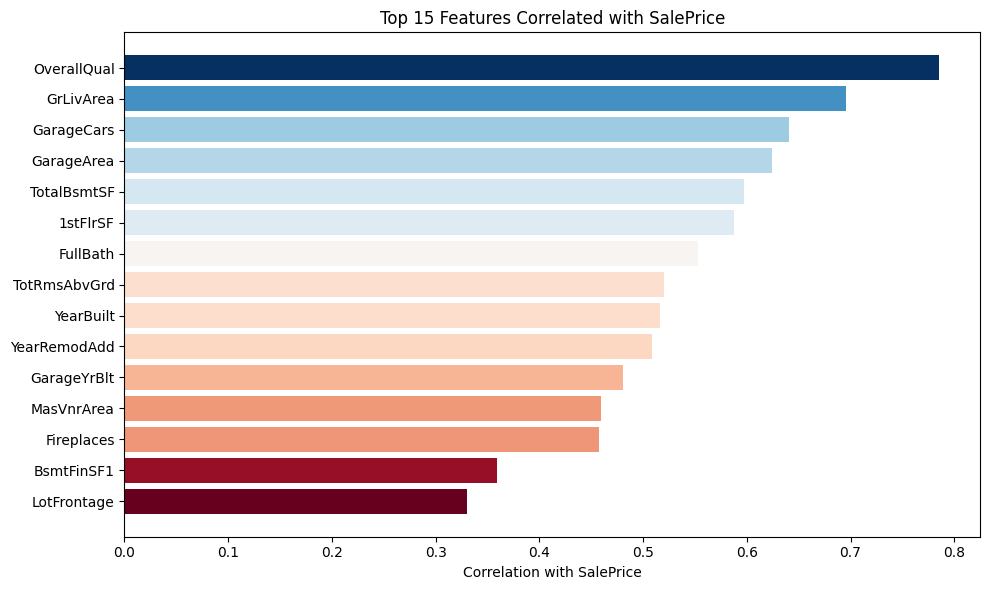

In [49]:
corr_with_target = X_train[numerical_cols].corrwith(y_train).sort_values(key=abs, ascending=False)

top_corr = corr_with_target.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
norm = plt.Normalize(vmin=top_corr.min(), vmax=top_corr.max())
colors = plt.cm.RdBu((top_corr.values - top_corr.min()) / (top_corr.max() - top_corr.min()))

plt.barh(range(len(top_corr))[::-1], top_corr.values, color=colors)
plt.yticks(range(len(top_corr))[::-1], top_corr.index)
plt.xlabel(f'Correlation with {y_train.name}')
plt.title(f'Top 15 Features Correlated with {y_train.name}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

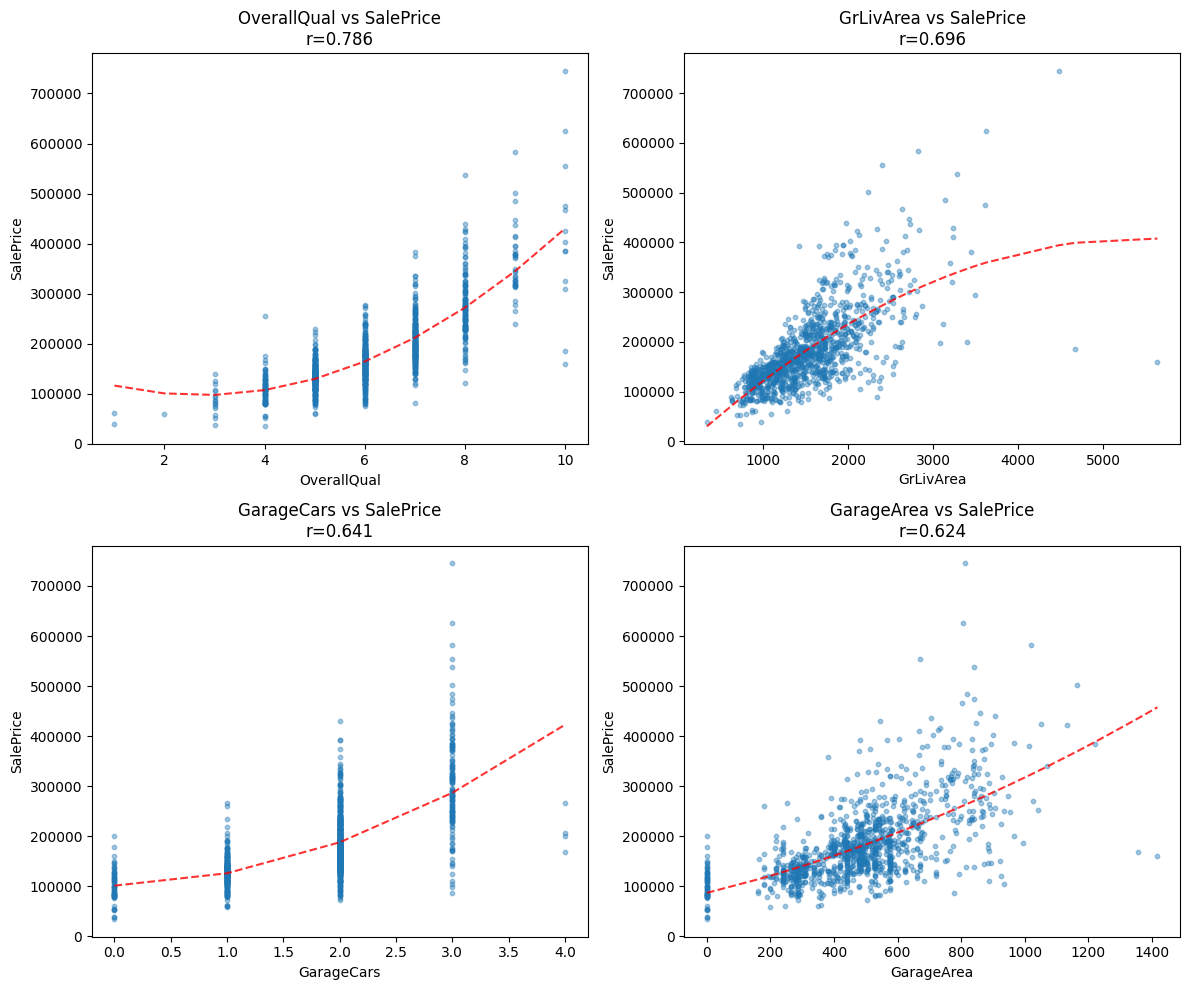

In [50]:
top_4_features = corr_with_target.abs().sort_values(ascending=False).head(4).index

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(top_4_features):
    axes[i].scatter(X_train[col], y_train, alpha=0.4, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(y_train.name)
    axes[i].set_title(f'{col} vs {y_train.name}\nr={corr_with_target[col]:.3f}')
    
    try:
        z = np.polyfit(X_train[col].dropna(), y_train[X_train[col].notna()], 2)
        p = np.poly1d(z)
        x_sorted = np.sort(X_train[col].dropna())
        axes[i].plot(x_sorted, p(x_sorted), "r--", alpha=0.8, label='Quadratic fit')
    except:
        pass

plt.tight_layout()
plt.show()

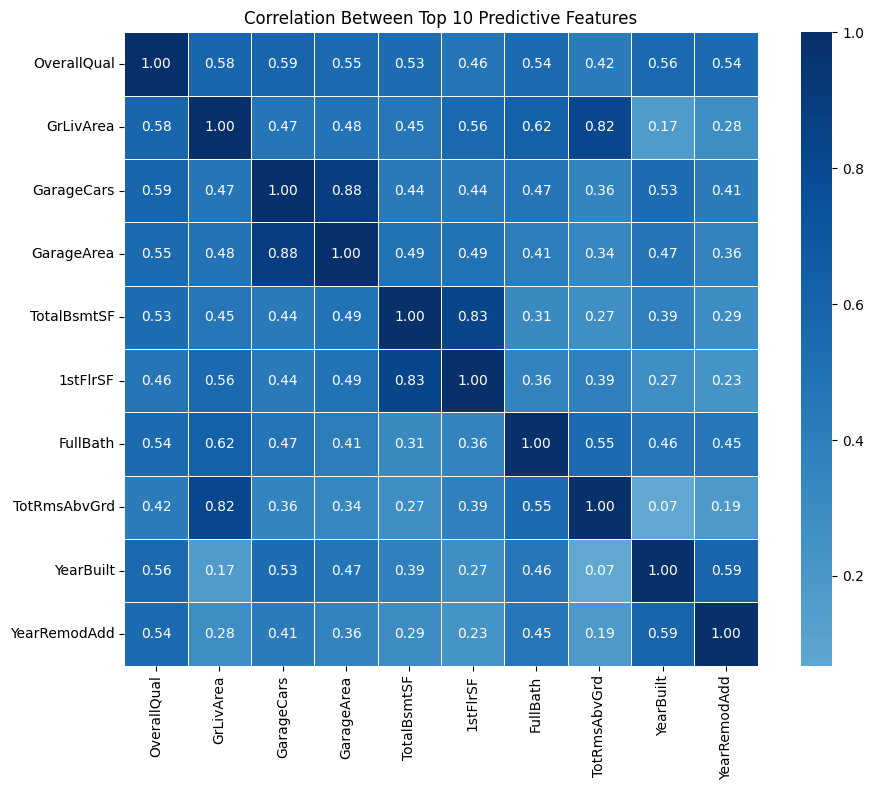

In [51]:
top_10_features = corr_with_target.abs().sort_values(ascending=False).head(10).index
corr_matrix = X_train[top_10_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', 
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Between Top 10 Predictive Features')
plt.tight_layout()

## Categorical feature importance and correlation

In [52]:
from sklearn.feature_selection import mutual_info_regression

# (simple one-hot for EDA)
X_encoded = pd.get_dummies(X_train[categorical_cols], dummy_na=True)

mi = mutual_info_regression(X_encoded, y_train)

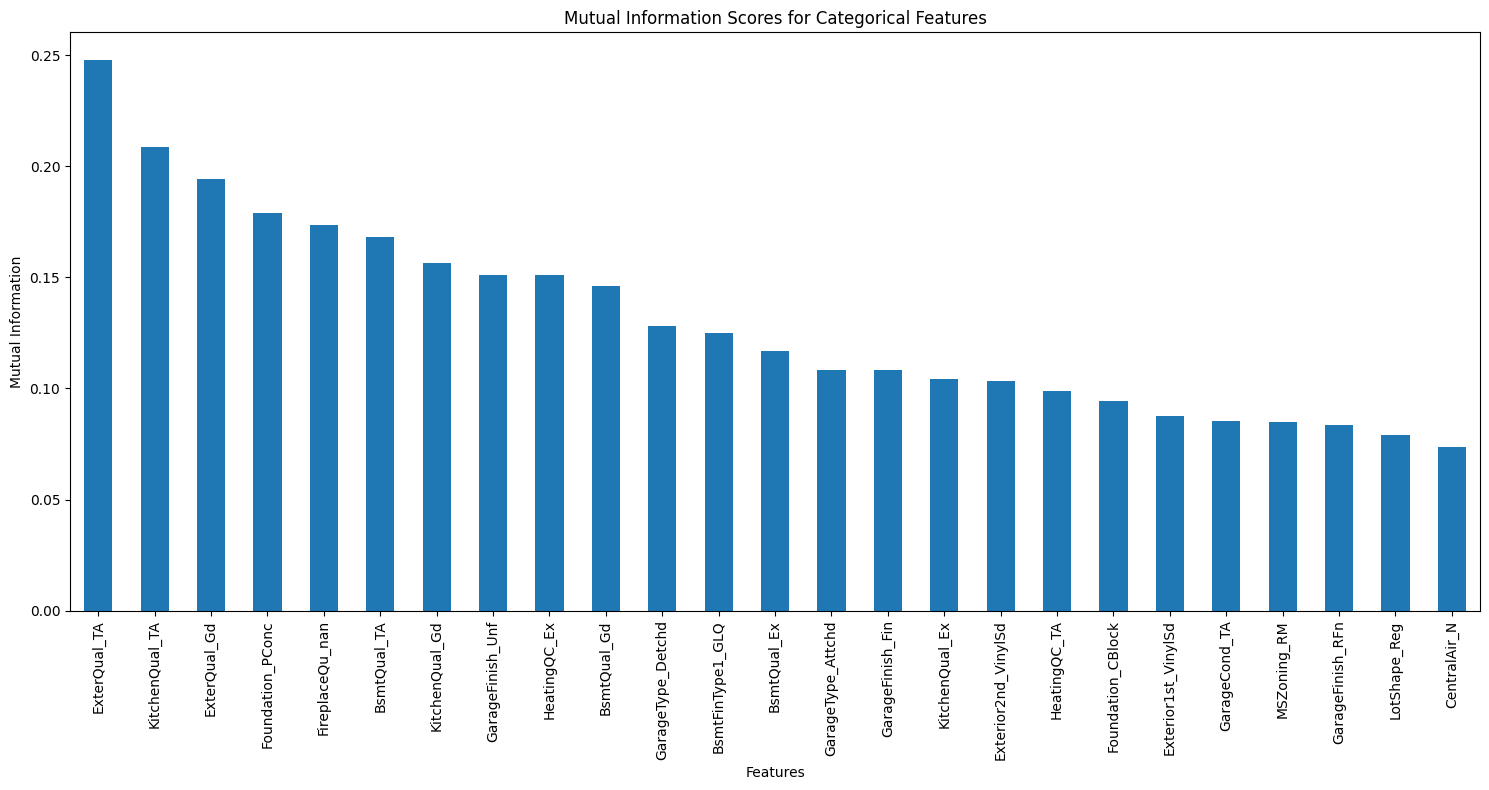

In [53]:
mi = pd.Series(mi, index=X_encoded.columns).sort_values(ascending=False).head(25)

plt.figure(figsize=(15, 8))
mi.plot(kind='bar')
plt.xticks(range(len(mi)), mi.index, rotation=90)
plt.title('Mutual Information Scores for Categorical Features')
plt.xlabel('Features')
plt.ylabel('Mutual Information')
plt.tight_layout()
plt.show()

In [54]:
scores = {}

for col in categorical_cols:
    means = X_train.join(y_train).groupby(col)["SalePrice"].mean()
    scores[col] = means.var()

sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
top_cat_features = [col for col, _ in sorted_scores[:6]]
print(top_cat_features)

['PoolQC', 'ExterQual', 'KitchenQual', 'BsmtQual', 'Condition2', 'FireplaceQu']


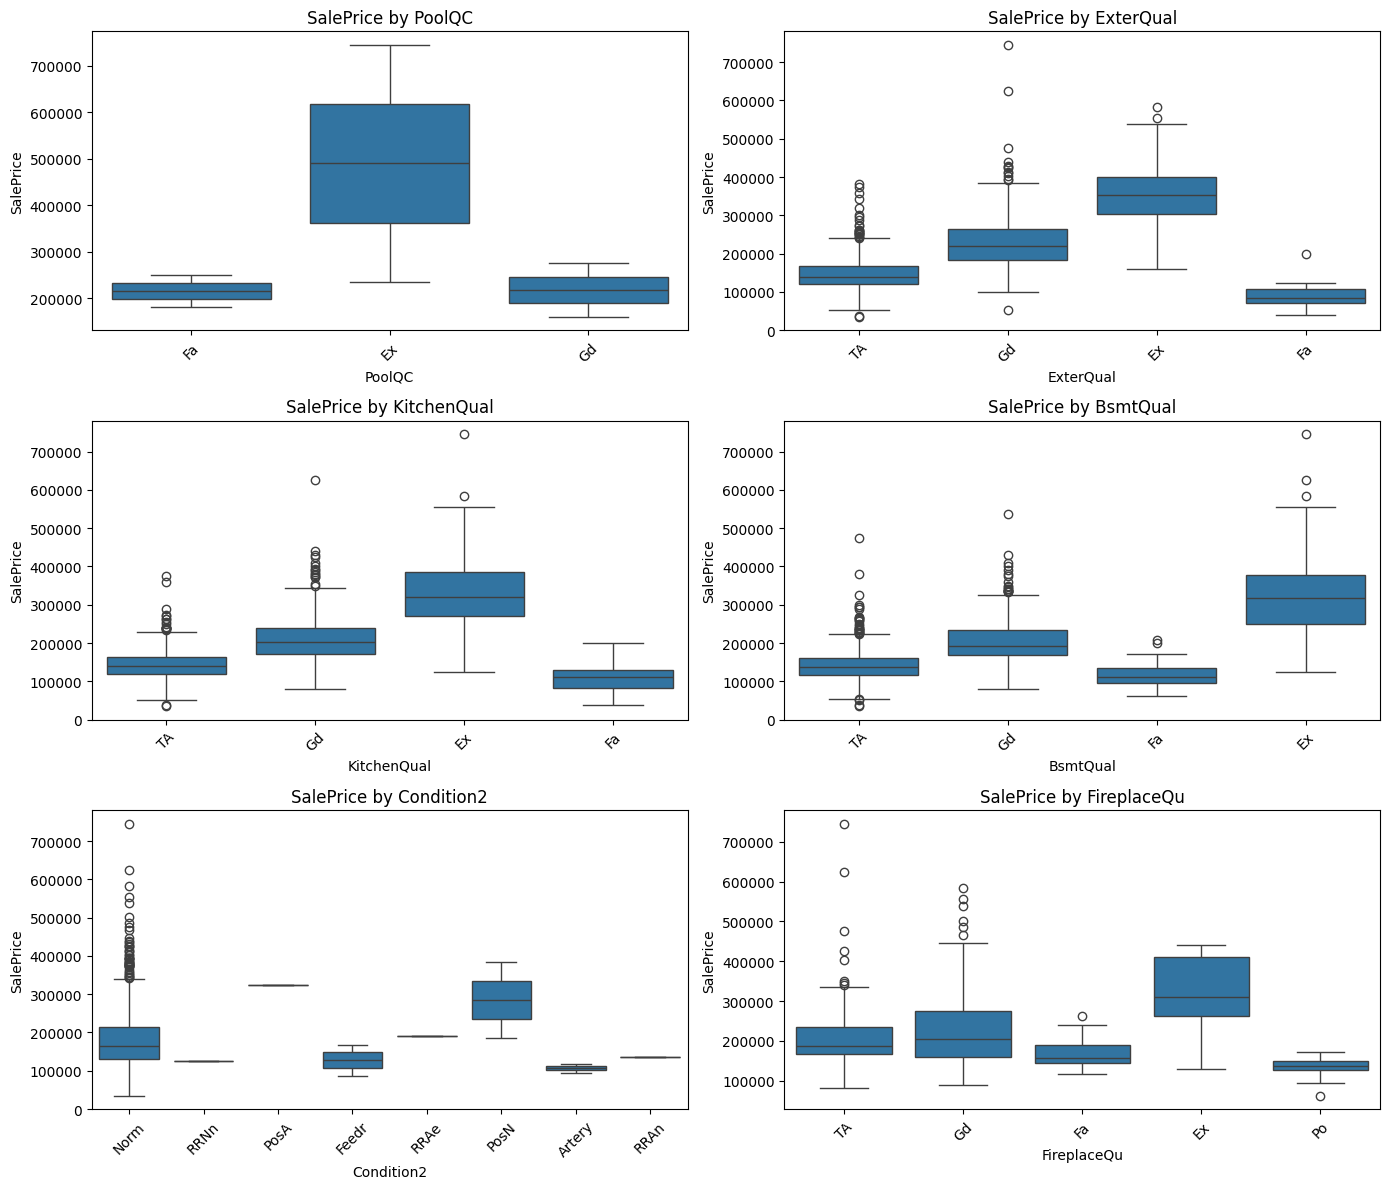

In [55]:
cat_df = X_train[top_cat_features].join(y_train)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(top_cat_features):
    sns.boxplot(x=col, y='SalePrice', data=cat_df, ax=axes[i])
    axes[i].set_title(f'SalePrice by {col}')
    axes[i].tick_params(axis='x', rotation=45)

for ax in axes[len(top_cat_features):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Sparse features that are mostly null or have a dominant category can be strong predictors.

In [56]:
for col in nulls_ratio.index:
    has_col = X_train[col].notna()
    mean_price = X_train.join(y_train).groupby(has_col)["SalePrice"].mean()
    print(f"{col} - Mean SalePrice with {col}: {mean_price[True]:.2f}, without {col}: {mean_price[False]:.2f}")

PoolQC - Mean SalePrice with PoolQC: 307661.67, without PoolQC: 180789.80
MiscFeature - Mean SalePrice with MiscFeature: 159181.52, without MiscFeature: 182354.16
Alley - Mean SalePrice with Alley: 142544.62, without Alley: 184072.60
Fence - Mean SalePrice with Fence: 155698.51, without Fence: 187856.65
MasVnrType - Mean SalePrice with MasVnrType: 213361.95, without MasVnrType: 158774.78
FireplaceQu - Mean SalePrice with FireplaceQu: 215549.78, without FireplaceQu: 142719.03
LotFrontage - Mean SalePrice with LotFrontage: 181601.47, without LotFrontage: 180740.67
GarageType - Mean SalePrice with GarageType: 186048.16, without GarageType: 101977.34
GarageYrBlt - Mean SalePrice with GarageYrBlt: 186048.16, without GarageYrBlt: 101977.34
GarageFinish - Mean SalePrice with GarageFinish: 186048.16, without GarageFinish: 101977.34
GarageQual - Mean SalePrice with GarageQual: 186048.16, without GarageQual: 101977.34
GarageCond - Mean SalePrice with GarageCond: 186048.16, without GarageCond: 10

# Data Cleaning

In [57]:
from sklearn.base import BaseEstimator, TransformerMixin

class DataCleaner(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Drop ID
        X = X.drop("Id", axis=1)
        X = X.drop("MiscFeature", axis=1)
        X = X.drop("MiscVal", axis=1)
        X = X.drop("Alley", axis=1)
        X = X.drop("Fence", axis=1)

        # Categorical NA to "None"
        cat_none_cols = [
            "PoolQC", "FireplaceQu",
            "GarageType", "GarageFinish", "GarageQual", "GarageCond",
            "BsmtQual", "BsmtCond", "BsmtExposure",
            "BsmtFinType1", "BsmtFinType2",
            "MasVnrType",
            #"MiscFeature", "Alley", "Fence"
        ]

        for col in cat_none_cols:
            if col in X:
                X[col] = X[col].fillna("None")

        # Numeric NA to 0 (for features where NA means "no feature")
        if "GarageYrBlt" in X:
            X["GarageYrBlt"] = X["GarageYrBlt"].fillna(0)

        if "MasVnrArea" in X:
            X["MasVnrArea"] = X["MasVnrArea"].fillna(0)

        # LotFrontage (Neighborhood group median)
        if "LotFrontage" in X:
            X["LotFrontage"] = X.groupby("Neighborhood")["LotFrontage"].transform(
                lambda x: x.fillna(x.median())
            )

        # Electrical (mode)
        if "Electrical" in X:
            X["Electrical"] = X["Electrical"].fillna(X["Electrical"].mode()[0])

        return X
    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

In [58]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

num_cols = [col for col in num_cols if col != "Id" and col != "MiscVal"]
cat_cols = [col for col in cat_cols if col != "Id" and col != "MiscFeature" and col != "Alley" and col != "Fence"]

# median since skewed numeric features exist
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")) 
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols),
    ]
)

# Feature Engineering

In [59]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Presence features
        X["HasGarage"] = (X["GarageType"] != "None").astype(int)
        X["HasPool"] = (X["PoolQC"] != "None").astype(int)
        X["HasMasVnr"] = (X["MasVnrType"] != "None").astype(int)
        X["HasFireplace"] = (X["FireplaceQu"] != "None").astype(int)

        # Total area
        X["TotalSF"] = X["TotalBsmtSF"] + X["1stFlrSF"] + X["2ndFlrSF"]

        return X
    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self


In [60]:
# or maybe use pipe.set_output(transform="pandas") and skip this but this is more flexible if we want to do custom feature engineering that needs column names.
class ColumnNameRestorer(BaseEstimator, TransformerMixin):
    def __init__(self, column_transformer):
        self.column_transformer = column_transformer

    def fit(self, X, y=None):
        self.feature_names_ = self.column_transformer.get_feature_names_out() # num and cat prefixes included
        return self

    def transform(self, X):
        return pd.DataFrame(X, columns=self.feature_names_)

# Feature Selection

In [61]:
class CorrelationReducer(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8, verbose=True):
        self.threshold = threshold
        self.verbose = verbose

    def fit(self, X, y=None):
        X_df = X.copy()
        self.feature_names_ = X_df.columns.tolist()

        corr_matrix = X_df.corr().abs()

        # upper triangle
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
        upper = corr_matrix.where(mask)

        to_remove = set()

        for col in upper.columns:
            correlated = upper[col][upper[col] > self.threshold].index.tolist()

            for other in correlated:
                # overall correlation strength
                col_score = corr_matrix[col].sum()
                other_score = corr_matrix[other].sum()

                if col_score > other_score:
                    to_remove.add(col)
                else:
                    to_remove.add(other)

        self.removed_features_ = list(to_remove)
        self.kept_features_ = [f for f in self.feature_names_ if f not in to_remove]

        if self.verbose:
            print(f"[Correlation] Removed {len(self.removed_features_)} features: {self.removed_features_}")
            print(f"[Correlation] Kept {len(self.kept_features_)} features: {self.kept_features_}")

        return self

    def transform(self, X):
        X_df = X.copy()
        X_df.columns = self.feature_names_

        return X_df[self.kept_features_]
    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

In [62]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression


class FeatureSelectorRFE(BaseEstimator, TransformerMixin):
    def __init__(self, n_features=20, verbose=True):
        self.n_features = n_features
        self.verbose = verbose

    def fit(self, X, y):
        X_df = X.copy()
        self.input_features_ = X_df.columns.tolist()

        model = LinearRegression()

        self.selector_ = RFE(
            estimator=model,
            n_features_to_select=self.n_features
        )
        self.selector_.fit(X_df, y)

        mask = self.selector_.support_
        self.selected_features_ = list(pd.Index(self.input_features_)[mask])

        if self.verbose:
            print(f"[RFE] Selected {len(self.selected_features_)} features: {self.selected_features_}")

        return self

    def transform(self, X):
        X_df = X.copy()
        X_df.columns = self.input_features_

        return X_df[self.selected_features_]
    def set_output(self, transform="pandas"):
        self._transform_output = transform
        return self

# Full Pipeline

In [63]:
preprocessing_pipeline = Pipeline([
    ("cleaner", DataCleaner()),
    ("feature_engineer", FeatureEngineer()),
    ("preprocessor", preprocessor),
    #("col_restorer", ColumnNameRestorer(preprocessor)),
    ("corr_reduce", CorrelationReducer(threshold=0.8)),
    ("rfe", FeatureSelectorRFE(n_features=20)),
])

preprocessing_pipeline.set_output(transform="pandas")

,steps,"[('cleaner', ...), ('feature_engineer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [64]:
import skops.io as sio
import mlflow

mlflow.set_experiment("house_prices_preprocessing")

# end any lingering active run..
if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="preprocessing_pipeline"):

    mlflow.log_param("num_impute_strategy", "median")
    mlflow.log_param("cat_impute_strategy", "most_frequent")
    mlflow.log_param("corr_threshold", 0.8)
    mlflow.log_param("rfe_n_features", 20)

    preprocessing_pipeline.fit(X_train, y_train)

    sio.dump(preprocessing_pipeline, "preprocessing_pipeline.skops")
    mlflow.log_artifact("preprocessing_pipeline.skops")

    preprocessing_run_id = mlflow.active_run().info.run_id
    print(f"Preprocessing run id: {preprocessing_run_id}")

X_train_transformed = preprocessing_pipeline.transform(X_train)
X_test_transformed  = preprocessing_pipeline.transform(X_test)

[Correlation] Removed 40 features: ['cat__RoofStyle_Flat', 'cat__BldgType_1Fam', 'cat__GarageQual_Ex', 'cat__LotShape_Reg', 'cat__GarageType_None', 'num__2ndFlrSF', 'cat__BsmtCond_None', 'cat__CentralAir_N', 'cat__Exterior2nd_Wd Sdng', 'cat__Exterior1st_CBlock', 'cat__BsmtQual_None', 'cat__BsmtExposure_None', 'cat__GarageFinish_None', 'cat__GarageQual_None', 'cat__SaleCondition_Partial', 'cat__FireplaceQu_None', 'cat__Utilities_AllPub', 'cat__Electrical_SBrkr', 'cat__Exterior1st_HdBoard', 'cat__Exterior2nd_CmentBd', 'num__GrLivArea', 'num__TotalBsmtSF', 'cat__PavedDrive_Y', 'cat__LandSlope_Gtl', 'cat__Street_Grvl', 'cat__BsmtFinType2_None', 'cat__MSZoning_RM', 'cat__Exterior1st_VinylSd', 'cat__MasVnrType_None', 'num__GarageYrBlt', 'cat__Exterior1st_MetalSd', 'num__GarageCars', 'cat__ExterQual_TA', 'cat__RoofStyle_Gable', 'cat__KitchenQual_TA', 'cat__Neighborhood_Somerst', 'cat__PoolQC_None', 'cat__BsmtFinType1_None', 'cat__ExterCond_TA', 'cat__Exterior1st_AsbShng']
[Correlation] Kept 2

c:\Users\Myvari\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


# Linear regression

In [65]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import skops.io as sio

kf = KFold(n_splits=5, shuffle=True, random_state=42)

mlflow.set_experiment("linear_regression_v1")

for target in [y_train_log, y_train]:  # try both log and raw target
    with mlflow.start_run(run_name="LinearRegression_LogTarget" if target is y_train_log else "LinearRegression_RawTarget"):
        y = target

        mlflow.set_tag("preprocessing_run_id", preprocessing_run_id)
        mlflow.set_tag("model_type", "LinearRegression")
        mlflow.set_tag("log_target", target is y_train_log)

        model = LinearRegression()

        # CV on log target
        cv_results = cross_validate(
            model,
            X_train_transformed,
            y,
            cv=kf,
            scoring=("neg_root_mean_squared_error", "r2"),
            return_train_score=True
        )

        # log metrics (convert from negative RMSE)
        train_rmse = -cv_results["train_neg_root_mean_squared_error"].mean()
        val_rmse   = -cv_results["test_neg_root_mean_squared_error"].mean()

        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("val_rmse",   val_rmse)
        mlflow.log_metric("train_r2",   cv_results["train_r2"].mean())
        mlflow.log_metric("val_r2",     cv_results["test_r2"].mean())

        mlflow.log_metric( "rmse_gap", val_rmse - train_rmse)

        # fit full model
        model.fit(X_train_transformed, y)

        preds = model.predict(X_test_transformed)
        if target is y_train_log:
            preds = np.expm1(preds)
        

        test_rmse = np.sqrt(mean_squared_error(y_test, preds))
        test_mae  = mean_absolute_error(y_test, preds)
        test_r2   = r2_score(y_test, preds)

        mlflow.log_metric("test_rmse", test_rmse)
        mlflow.log_metric("test_mae", test_mae)
        mlflow.log_metric("test_r2", test_r2)

        sio.dump(model, "model.skops")
        mlflow.log_artifact("model.skops")

        print(f"is Log-Target: {target is y_train_log} | val_rmse={val_rmse:.4f} | rmse_gap={val_rmse - test_rmse:.4f} | test_rmse={test_rmse:.4f} | test_mae={test_mae:.4f} | test_r2={test_r2:.4f}")


2026/04/13 19:56:50 INFO mlflow.tracking.fluent: Experiment with name 'linear_regression_v1' does not exist. Creating a new experiment.


is Log-Target: True | val_rmse=0.2498 | rmse_gap=-58371.5953 | test_rmse=58371.8452 | test_mae=35825.5423 | test_r2=0.5558
🏃 View run LinearRegression_LogTarget at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/6/runs/d6cedeb4554d4b028886b5b860c9de35
🧪 View experiment at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/6
is Log-Target: False | val_rmse=47546.2682 | rmse_gap=-1901.2186 | test_rmse=49447.4869 | test_mae=34965.4598 | test_r2=0.6812
🏃 View run LinearRegression_RawTarget at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/6/runs/33cf1c8512b4473b992b87f4245c2468
🧪 View experiment at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/6


# Decision Tree

In [66]:
from sklearn.tree import DecisionTreeRegressor

param_grid_dt = [
    # very shallow - strong underfitting
    {"max_depth": 2,  "min_samples_split": 2,  "min_samples_leaf": 1,  "criterion": "squared_error"},
    {"max_depth": 2,  "min_samples_split": 5,  "min_samples_leaf": 2,  "criterion": "absolute_error"},

    # shallow
    {"max_depth": 4,  "min_samples_split": 2,  "min_samples_leaf": 1,  "criterion": "squared_error"},
    {"max_depth": 4,  "min_samples_split": 5,  "min_samples_leaf": 2,  "criterion": "friedman_mse"},

    # medium complexity
    {"max_depth": 6,  "min_samples_split": 2,  "min_samples_leaf": 1,  "criterion": "squared_error"},
    {"max_depth": 6,  "min_samples_split": 10, "min_samples_leaf": 4,  "criterion": "friedman_mse"},

    # deeper trees - lower bias, higher variance
    {"max_depth": 10, "min_samples_split": 2,  "min_samples_leaf": 1,  "criterion": "squared_error"},
    {"max_depth": 10, "min_samples_split": 5,  "min_samples_leaf": 2,  "criterion": "absolute_error"},

    # nearly unrestricted - strong overfitting expected
    {"max_depth": None, "min_samples_split": 2,  "min_samples_leaf": 1,  "criterion": "squared_error"},
    {"max_depth": None, "min_samples_split": 10, "min_samples_leaf": 5,  "criterion": "friedman_mse"},
]

mlflow.set_experiment("decision_tree_v1")

for target in [y_train_log, y_train]:
    for params in param_grid_dt:
        target_name = "LogTarget" if target is y_train_log else "RawTarget"
        with mlflow.start_run(run_name=f"Tree_depth{params['max_depth']}_criterion{params['criterion']}_split{params['min_samples_split']}_leaf{params['min_samples_leaf']}_{target_name}"):
            y = target

            mlflow.set_tag("preprocessing_run_id", preprocessing_run_id)
            mlflow.set_tag("model_type", "DecisionTreeRegressor")
            mlflow.set_tag("log_target", target is y_train_log)

            model = DecisionTreeRegressor(**params, random_state=42)

            cv_results = cross_validate(
                model,
                X_train_transformed,
                y,
                cv=kf,
                scoring=("neg_root_mean_squared_error", "r2"),
                return_train_score=True
            )

            mlflow.log_params(params)

            train_rmse = -cv_results["train_neg_root_mean_squared_error"].mean()
            val_rmse   = -cv_results["test_neg_root_mean_squared_error"].mean()

            mlflow.log_metric("train_rmse", train_rmse)
            mlflow.log_metric("val_rmse", val_rmse)
            mlflow.log_metric("train_r2",   cv_results["train_r2"].mean())
            mlflow.log_metric("val_r2",     cv_results["test_r2"].mean())

            # overfitting gap
            mlflow.log_metric("rmse_gap", val_rmse - train_rmse)

            model.fit(X_train_transformed, y)
            preds = model.predict(X_test_transformed)
            if target is y_train_log:
                preds = np.expm1(preds)

            test_rmse = np.sqrt(mean_squared_error(y_test, preds))
            test_mae  = mean_absolute_error(y_test, preds)
            test_r2   = r2_score(y_test, preds)

            mlflow.log_metric("test_rmse", test_rmse)
            mlflow.log_metric("test_mae", test_mae)
            mlflow.log_metric("test_r2", test_r2)

            sio.dump(model, "model.skops")
            mlflow.log_artifact("model.skops")

            print(f"is Log-Target: {target is y_train_log}, depth={params['max_depth']}, split={params['min_samples_split']}, leaf={params['min_samples_leaf']}, criterion={params['criterion']}"
              f"leaf={params['min_samples_leaf']} {params['criterion']} | "
              f"val_rmse={val_rmse:.4f} | "
              f"rmse_gap={train_rmse - val_rmse:.4f} | "
              f"test_rmse={test_rmse:.4f}")


            

2026/04/13 19:57:17 INFO mlflow.tracking.fluent: Experiment with name 'decision_tree_v1' does not exist. Creating a new experiment.


is Log-Target: True, depth=2, split=2, leaf=1, criterion=squared_errorleaf=1 squared_error | val_rmse=0.2892 | rmse_gap=-0.0050 | test_rmse=64599.3693
🏃 View run Tree_depth2_criterionsquared_error_split2_leaf1_LogTarget at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/7/runs/100a2314f7f147a488ea6d06e207b06b
🧪 View experiment at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/7
is Log-Target: True, depth=2, split=5, leaf=2, criterion=absolute_errorleaf=2 absolute_error | val_rmse=0.2903 | rmse_gap=-0.0053 | test_rmse=65173.6284
🏃 View run Tree_depth2_criterionabsolute_error_split5_leaf2_LogTarget at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/7/runs/983e1e95578c4ebfb6b6e816c8e5d4c6
🧪 View experiment at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/7
is Log-Target: True, depth=4, split=2, leaf=1, criterion=squared_errorleaf=1 squared_error | val_rmse=0.2629 | rmse_gap=-0.0095 | test_rmse=54133.9391
🏃 View run Tree_depth4_cri

# Random Forest

In [67]:
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = [
    # shallow forests - likely underfitting
    {"n_estimators": 100, "max_depth": 3,  "min_samples_split": 2,  "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 3,  "min_samples_split": 5,  "min_samples_leaf": 2},

    # medium complexity
    {"n_estimators": 100, "max_depth": 5,  "min_samples_split": 2,  "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 5,  "min_samples_split": 5,  "min_samples_leaf": 2},
    {"n_estimators": 200, "max_depth": 5,  "min_samples_split": 10, "min_samples_leaf": 4},

    # deeper forests
    {"n_estimators": 200, "max_depth": 10, "min_samples_split": 2,  "min_samples_leaf": 1},
    {"n_estimators": 200, "max_depth": 10, "min_samples_split": 5,  "min_samples_leaf": 2},

    # fully grown
    {"n_estimators": 300, "max_depth": None, "min_samples_split": 2,  "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": None, "min_samples_split": 10, "min_samples_leaf": 5},
]

mlflow.set_experiment("random_forest_v1")

for target in [y_train_log, y_train]:
    target_name = "LogTarget" if target is y_train_log else "RawTarget"

    for params in param_grid_rf:
        run_name = (
            f"RF_depth{params['max_depth']}_"
            f"split{params['min_samples_split']}_"
            f"leaf{params['min_samples_leaf']}_"
            f"estimators{params['n_estimators']}"
            f"_{target_name}"
        )

        with mlflow.start_run(run_name=run_name):
            y = target

            mlflow.set_tag("preprocessing_run_id", preprocessing_run_id)
            mlflow.set_tag("model_type", "RandomForestRegressor")
            mlflow.set_tag("log_target", target is y_train_log)

            mlflow.log_params(params)

            model = RandomForestRegressor(
                **params,
                random_state=42,
                n_jobs=-1
            )

            cv_results = cross_validate(
                model,
                X_train_transformed,
                y,
                cv=kf,
                scoring=("neg_root_mean_squared_error", "r2"),
                return_train_score=True,
                n_jobs=-1
            )

            train_rmse = -cv_results["train_neg_root_mean_squared_error"].mean()
            val_rmse = -cv_results["test_neg_root_mean_squared_error"].mean()
            train_r2 = cv_results["train_r2"].mean()
            val_r2 = cv_results["test_r2"].mean()

            mlflow.log_metric("train_rmse", train_rmse)
            mlflow.log_metric("val_rmse", val_rmse)
            mlflow.log_metric("train_r2", train_r2)
            mlflow.log_metric("val_r2", val_r2)
            mlflow.log_metric("rmse_gap", val_rmse - train_rmse)

            model.fit(X_train_transformed, y)

            preds = model.predict(X_test_transformed)
            if target is y_train_log:
                preds = np.expm1(preds)


            test_rmse = np.sqrt(mean_squared_error(y_test, preds))
            test_mae = mean_absolute_error(y_test, preds)
            test_r2 = r2_score(y_test, preds)

            mlflow.log_metric("test_rmse", test_rmse)
            mlflow.log_metric("test_mae", test_mae)
            mlflow.log_metric("test_r2", test_r2)

            sio.dump(model, "rf_model.skops")
            mlflow.log_artifact("rf_model.skops")

            print(
                f"is Log-Target: {target is y_train_log} | "
                f"depth={params['max_depth']} | "
                f"split={params['min_samples_split']} | "
                f"leaf={params['min_samples_leaf']} | "
                f"estimators={params['n_estimators']} | "
                f"val_rmse={val_rmse:.4f} | "
                f"test_rmse={test_rmse:.4f} | "
                f"test_mae={test_mae:.4f} | "
                f"test_r2={test_r2:.4f}"
            )

2026/04/13 20:03:00 INFO mlflow.tracking.fluent: Experiment with name 'random_forest_v1' does not exist. Creating a new experiment.


is Log-Target: True | depth=3 | split=2 | leaf=1 | estimators=100 | val_rmse=0.2630 | test_rmse=55654.6017 | test_mae=36969.9729 | test_r2=0.5962
🏃 View run RF_depth3_split2_leaf1_estimators100_LogTarget at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/8/runs/45bd5d48eb7448249d12b71477d0990d
🧪 View experiment at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/8
is Log-Target: True | depth=3 | split=5 | leaf=2 | estimators=100 | val_rmse=0.2633 | test_rmse=55156.0009 | test_mae=36812.8028 | test_r2=0.6034
🏃 View run RF_depth3_split5_leaf2_estimators100_LogTarget at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/8/runs/139c3e91264243bc8d8b6a69acb534f4
🧪 View experiment at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/8
is Log-Target: True | depth=5 | split=2 | leaf=1 | estimators=100 | val_rmse=0.2530 | test_rmse=52911.4953 | test_mae=35711.6580 | test_r2=0.6350
🏃 View run RF_depth5_split2_leaf1_estimators100_LogTarget at: http

# Boosted Tree with XGBoost

In [68]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_validate

param_grid_xgb = [
    # conservative - likely underfitting
    {
        "n_estimators": 100,
        "learning_rate": 0.10,
        "max_depth": 3,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 3,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },

    # balanced
    {
        "n_estimators": 200,
        "learning_rate": 0.10,
        "max_depth": 4,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "max_depth": 4,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },

    # deeper - stronger
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 5,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 300,
        "learning_rate": 0.03,
        "max_depth": 5,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },

    # regularized with subsampling
    {
        "n_estimators": 300,
        "learning_rate": 0.05,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.03,
        "max_depth": 5,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },

    # more aggressive - may overfit
    {
        "n_estimators": 500,
        "learning_rate": 0.03,
        "max_depth": 6,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    {
        "n_estimators": 500,
        "learning_rate": 0.01,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8
    },
]

mlflow.set_experiment("xgboost_v1")

for target in [y_train_log, y_train]:
    target_name = "LogTarget" if target is y_train_log else "RawTarget"

    for params in param_grid_xgb:
        run_name = (
            f"XGB_depth{params['max_depth']}_"
            f"lr{params['learning_rate']}_"
            f"est{params['n_estimators']}_"
            f"sub{params['subsample']}_"
            f"col{params['colsample_bytree']}"
            f"_{target_name}"
        )

        with mlflow.start_run(run_name=run_name):
            y = target

            mlflow.set_tag("preprocessing_run_id", preprocessing_run_id)
            mlflow.set_tag("model_type", "XGBRegressor")
            mlflow.set_tag("log_target", target is y_train_log)

            mlflow.log_params(params)

            model = XGBRegressor(
                **params,
                random_state=42,
                objective="reg:squarederror",
                n_jobs=-1
            )

            cv_results = cross_validate(
                model,
                X_train_transformed,
                y,
                cv=kf,
                scoring=("neg_root_mean_squared_error", "r2"),
                return_train_score=True,
                n_jobs=1
            )

            train_rmse = -cv_results["train_neg_root_mean_squared_error"].mean()
            val_rmse = -cv_results["test_neg_root_mean_squared_error"].mean()
            train_r2 = cv_results["train_r2"].mean()
            val_r2 = cv_results["test_r2"].mean()

            mlflow.log_metric("train_rmse", train_rmse)
            mlflow.log_metric("val_rmse", val_rmse)
            mlflow.log_metric("train_r2", train_r2)
            mlflow.log_metric("val_r2", val_r2)
            mlflow.log_metric("rmse_gap", val_rmse - train_rmse)

            model.fit(X_train_transformed, y)

            preds = model.predict(X_test_transformed)
            if target is y_train_log:
                preds = np.expm1(preds)

            test_rmse = np.sqrt(mean_squared_error(y_test, preds))
            test_mae = mean_absolute_error(y_test, preds)
            test_r2 = r2_score(y_test, preds)

            mlflow.log_metric("test_rmse", test_rmse)
            mlflow.log_metric("test_mae", test_mae)
            mlflow.log_metric("test_r2", test_r2)

            sio.dump(model, "xgb_model.skops")
            mlflow.log_artifact("xgb_model.skops")

            print(
                f"is Log-Target: {target is y_train_log} | "
                f"depth={params['max_depth']} | "
                f"lr={params['learning_rate']} | "
                f"estimators={params['n_estimators']} | "
                f"subsample={params['subsample']} | "
                f"colsample={params['colsample_bytree']} | "
                f"val_rmse={val_rmse:.4f} | "
                f"test_rmse={test_rmse:.4f} | "
                f"test_mae={test_mae:.4f} | "
                f"test_r2={test_r2:.4f}"
            )

2026/04/13 20:08:13 INFO mlflow.tracking.fluent: Experiment with name 'xgboost_v1' does not exist. Creating a new experiment.


is Log-Target: True | depth=3 | lr=0.1 | estimators=100 | subsample=1.0 | colsample=1.0 | val_rmse=0.2471 | test_rmse=48724.9863 | test_mae=33887.4023 | test_r2=0.6905
🏃 View run XGB_depth3_lr0.1_est100_sub1.0_col1.0_LogTarget at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/9/runs/474dc2a8677f46ca8a03e84f59547101
🧪 View experiment at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/9
is Log-Target: True | depth=3 | lr=0.05 | estimators=100 | subsample=1.0 | colsample=1.0 | val_rmse=0.2480 | test_rmse=48899.3454 | test_mae=33871.5898 | test_r2=0.6883
🏃 View run XGB_depth3_lr0.05_est100_sub1.0_col1.0_LogTarget at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/9/runs/aaf6c5f642b946268290b8d08b74ba9b
🧪 View experiment at: https://dagshub.com/myvari/House-Prices.mlflow/#/experiments/9
is Log-Target: True | depth=4 | lr=0.1 | estimators=200 | subsample=1.0 | colsample=1.0 | val_rmse=0.2482 | test_rmse=50087.9559 | test_mae=34601.2578 | test_r2=0.6

In [80]:
print(mlflow.search_runs(
    experiment_names=["linear_regression_v1", "decision_tree_v1", "random_forest_v1", "xgboost_v1"],
    order_by=["metrics.test_rmse ASC", "metrics.rmse_gap ASC", "metrics.test_r2 DESC"]
)[['tags.mlflow.runName', 'metrics.rmse_gap', 'metrics.test_r2', 'metrics.test_rmse', 'metrics.train_rmse', 'metrics.val_rmse', 'tags.log_target']].to_markdown(index=False))

| tags.mlflow.runName                                          |   metrics.rmse_gap |   metrics.test_r2 |   metrics.test_rmse |   metrics.train_rmse |   metrics.val_rmse | tags.log_target   |
|:-------------------------------------------------------------|-------------------:|------------------:|--------------------:|---------------------:|-------------------:|:------------------|
| XGB_depth3_lr0.1_est100_sub1.0_col1.0_LogTarget              |         0.0131333  |          0.690479 |             48725   |             0.233936 |           0.24707  | True              |
| XGB_depth3_lr0.05_est100_sub1.0_col1.0_LogTarget             |         0.0109968  |          0.68826  |             48899.3 |             0.23704  |           0.248037 | True              |
| XGB_depth5_lr0.03_est500_sub0.8_col0.8_LogTarget             |         0.0166353  |          0.682683 |             49334.9 |             0.232201 |           0.248837 | True              |
| LinearRegression_RawTarget            

In [81]:
print(DataCleaner)

<class '__main__.DataCleaner'>


In [82]:
print(DataCleaner.__module__)

__main__
